<a href="https://colab.research.google.com/github/Ariana-0212/Prediccion-Calidad-Aire-CDMX/blob/main/Prediccion_Calidad_Aire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from google.colab import files

uploaded = files.upload()

Saving Datos SINAICA - Presidencia Municipal - VV - .xls to Datos SINAICA - Presidencia Municipal - VV - .xls
Saving Datos SINAICA - Presidencia Municipal - TMP -xls to Datos SINAICA - Presidencia Municipal - TMP -xls
Saving Datos SINAICA - Presidencia Municipal - PB -.xls to Datos SINAICA - Presidencia Municipal - PB -.xls
Saving Datos SINAICA - Presidencia Municipal - PP - .xls to Datos SINAICA - Presidencia Municipal - PP - .xls
Saving Datos SINAICA - Presidencia Municipal - DV -.xls to Datos SINAICA - Presidencia Municipal - DV -.xls
Saving Datos SINAICA - Presidencia Municipal - HR -.xls to Datos SINAICA - Presidencia Municipal - HR -.xls
Saving Datos SINAICA - Presidencia Municipal - PM2.5 -.xls to Datos SINAICA - Presidencia Municipal - PM2.5 -.xls


In [30]:
import xml.etree.ElementTree as ET
import pandas as pd

import xml.etree.ElementTree as ET
import pandas as pd

def leer_sinaica(archivo,nombre_variable):

    with open(archivo,'r',encoding='utf-8',errors='ignore') as f:
        xml_data=f.read()

    xml_data = xml_data.replace("ss:","")

    root = ET.fromstring(xml_data)

    filas=[]

    for row in root.iter('{urn:schemas-microsoft-com:office:spreadsheet}Row'):

        datos=[]

        for cell in row:

            texto=""

            for item in cell:
                texto=item.text

            datos.append(texto)

        filas.append(datos)

    df = pd.DataFrame(filas)

    df = df.iloc[2:]

    ncols = df.shape[1]

    print(f"{archivo} -> {ncols} columnas")

    if ncols == 5:

        df.columns = [
            "Parametro",
            "Fecha",
            "Hora",
            nombre_variable,
            "Unidad"
        ]

    elif ncols == 4:

        df.columns = [
            "Parametro",
            "Fecha",
            nombre_variable,
            "Unidad"
        ]

    else:
        print("Estructura inesperada")
        print(df.head())

    return df

In [28]:
import os

for archivo in os.listdir():
    print(archivo)

.config
Datos SINAICA - Presidencia Municipal - HR -.xls
Datos SINAICA - Presidencia Municipal - TMP -xls
Datos SINAICA - Presidencia Municipal - VV - .xls
Datos SINAICA - Presidencia Municipal - PB -.xls
Datos SINAICA - Presidencia Municipal - PP - .xls
Datos SINAICA - Presidencia Municipal - PM2.5 -.xls
Datos SINAICA - Presidencia Municipal - DV -.xls
sample_data


In [29]:
import os

for archivo in os.listdir():
    print(repr(archivo))

'.config'
'Datos SINAICA - Presidencia Municipal - HR -.xls'
'Datos SINAICA - Presidencia Municipal - TMP -xls'
'Datos SINAICA - Presidencia Municipal - VV - .xls'
'Datos SINAICA - Presidencia Municipal - PB -.xls'
'Datos SINAICA - Presidencia Municipal - PP - .xls'
'Datos SINAICA - Presidencia Municipal - PM2.5 -.xls'
'Datos SINAICA - Presidencia Municipal - DV -.xls'
'sample_data'


In [13]:
import os
print(os.getcwd())

/content


In [26]:
print(os.path.exists('Datos SINAICA - Presidencia Municipal - PM2.5 -.xls'))

True


In [31]:
pm25 = leer_sinaica(
    'Datos SINAICA - Presidencia Municipal - PM2.5 -.xls',
    'PM25'
)

Datos SINAICA - Presidencia Municipal - PM2.5 -.xls -> 5 columnas


In [33]:
tmp = leer_sinaica(
'Datos SINAICA - Presidencia Municipal - TMP -xls',
'Temperatura'
)

Datos SINAICA - Presidencia Municipal - TMP -xls -> 4 columnas


In [34]:
import os

archivos = os.listdir()

for a in archivos:
    if "VV" in a:
        print(repr(a))

'Datos SINAICA - Presidencia Municipal - VV - .xls'


In [35]:
nombre_vv = [a for a in os.listdir() if "VV" in a][0]

vv = leer_sinaica(
    nombre_vv,
    'VelocidadViento'
)

Datos SINAICA - Presidencia Municipal - VV - .xls -> 4 columnas


In [36]:
pm25 = leer_sinaica(
    [a for a in os.listdir() if "PM2.5" in a][0],
    "PM25"
)

tmp = leer_sinaica(
    [a for a in os.listdir() if "TMP" in a][0],
    "Temperatura"
)

hr = leer_sinaica(
    [a for a in os.listdir() if "HR" in a][0],
    "Humedad"
)

vv = leer_sinaica(
    [a for a in os.listdir() if "VV" in a][0],
    "VelocidadViento"
)

pb = leer_sinaica(
    [a for a in os.listdir() if "PB" in a][0],
    "Presion"
)

pp = leer_sinaica(
    [a for a in os.listdir() if "PP" in a][0],
    "Lluvia"
)

Datos SINAICA - Presidencia Municipal - PM2.5 -.xls -> 5 columnas
Datos SINAICA - Presidencia Municipal - TMP -xls -> 4 columnas
Datos SINAICA - Presidencia Municipal - HR -.xls -> 4 columnas
Datos SINAICA - Presidencia Municipal - VV - .xls -> 4 columnas
Datos SINAICA - Presidencia Municipal - PB -.xls -> 4 columnas
Datos SINAICA - Presidencia Municipal - PP - .xls -> 4 columnas


In [37]:
print(pm25.shape)
print(tmp.shape)
print(hr.shape)
print(vv.shape)
print(pb.shape)
print(pp.shape)

(7618, 5)
(7834, 4)
(6245, 4)
(6597, 4)
(6601, 4)
(8, 4)


In [38]:
print(pm25.columns)
print(tmp.columns)
print(hr.columns)
print(vv.columns)
print(pb.columns)
print(pp.columns)

Index(['Parametro', 'Fecha', 'Hora', 'PM25', 'Unidad'], dtype='object')
Index(['Parametro', 'Fecha', 'Temperatura', 'Unidad'], dtype='object')
Index(['Parametro', 'Fecha', 'Humedad', 'Unidad'], dtype='object')
Index(['Parametro', 'Fecha', 'VelocidadViento', 'Unidad'], dtype='object')
Index(['Parametro', 'Fecha', 'Presion', 'Unidad'], dtype='object')
Index(['Parametro', 'Fecha', 'Lluvia', 'Unidad'], dtype='object')


In [39]:
pm25 = pm25[['Fecha','PM25']]

tmp = tmp[['Fecha','Temperatura']]

hr = hr[['Fecha','Humedad']]

vv = vv[['Fecha','VelocidadViento']]

pb = pb[['Fecha','Presion']]

In [40]:
pm25["PM25"] = pd.to_numeric(pm25["PM25"], errors="coerce")

tmp["Temperatura"] = pd.to_numeric(tmp["Temperatura"], errors="coerce")

hr["Humedad"] = pd.to_numeric(hr["Humedad"], errors="coerce")

vv["VelocidadViento"] = pd.to_numeric(vv["VelocidadViento"], errors="coerce")

pb["Presion"] = pd.to_numeric(pb["Presion"], errors="coerce")

In [41]:
pm25 = pm25.groupby("Fecha").mean().reset_index()

tmp = tmp.groupby("Fecha").mean().reset_index()

hr = hr.groupby("Fecha").mean().reset_index()

vv = vv.groupby("Fecha").mean().reset_index()

pb = pb.groupby("Fecha").mean().reset_index()

In [42]:
print(pm25.shape)
print(tmp.shape)
print(hr.shape)
print(vv.shape)
print(pb.shape)

(349, 2)
(351, 2)
(295, 2)
(295, 2)
(295, 2)


In [43]:
df = pm25.merge(tmp,on="Fecha")
df = df.merge(hr,on="Fecha")
df = df.merge(vv,on="Fecha")
df = df.merge(pb,on="Fecha")

In [44]:
df["MalaCalidad"] = (df["PM25"] >= 35).astype(int)

In [45]:
print(df["MalaCalidad"].value_counts())

MalaCalidad
0    293
1      1
Name: count, dtype: int64


In [46]:
print(df["PM25"].describe())

count    294.000000
mean      13.204199
std        6.842802
min        2.375000
25%        8.468750
50%       11.923611
75%       16.656250
max       64.333333
Name: PM25, dtype: float64


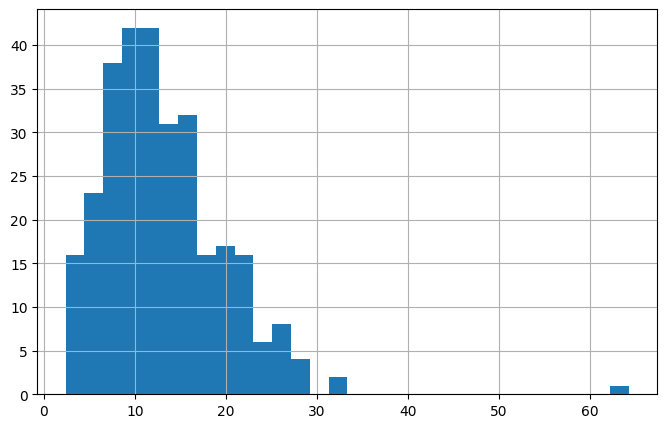

In [47]:
plt.figure(figsize=(8,5))
df["PM25"].hist(bins=30)
plt.show()

In [48]:
umbral = df["PM25"].median()

print("Umbral:", umbral)

df["MalaCalidad"] = (df["PM25"] >= umbral).astype(int)

print(df["MalaCalidad"].value_counts())

Umbral: 11.92361111111111
MalaCalidad
0    147
1    147
Name: count, dtype: int64


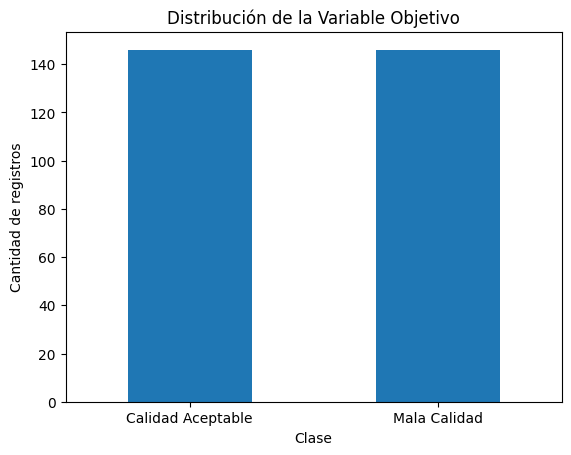

In [58]:
import matplotlib.pyplot as plt

df["MalaCalidad"].value_counts().plot(kind="bar")

plt.title("Distribución de la Variable Objetivo")
plt.xlabel("Clase")
plt.ylabel("Cantidad de registros")
plt.xticks([0,1],["Calidad Aceptable","Mala Calidad"], rotation=0)

plt.show()

In [49]:
df["PM25_Ayer"] = df["PM25"].shift(1)

df["PM25_Media3"] = df["PM25"].rolling(3).mean()

df = df.dropna()

In [50]:
X = df[
[
    "Temperatura",
    "Humedad",
    "VelocidadViento",
    "Presion",
    "PM25_Ayer",
    "PM25_Media3"
]
]

y = df["MalaCalidad"]

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

Modelo 1: Regresión Logística

In [52]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

Modelo 2: Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

Modelo 3: Gradient Boosting

In [54]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

Modelo 4: Red Neuronal

In [55]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50,25),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train, y_train)

pred_mlp = mlp.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score

resultados = pd.DataFrame({

    "Modelo":[
        "Logistica",
        "Random Forest",
        "Gradient Boosting",
        "Red Neuronal"
    ],

    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_gb),
        accuracy_score(y_test,pred_mlp)
    ]
})

print(resultados)

              Modelo  Accuracy
0          Logistica  0.829545
1      Random Forest  0.863636
2  Gradient Boosting  0.875000
3       Red Neuronal  0.806818


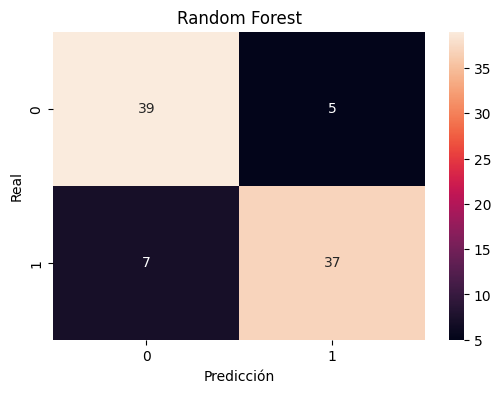

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

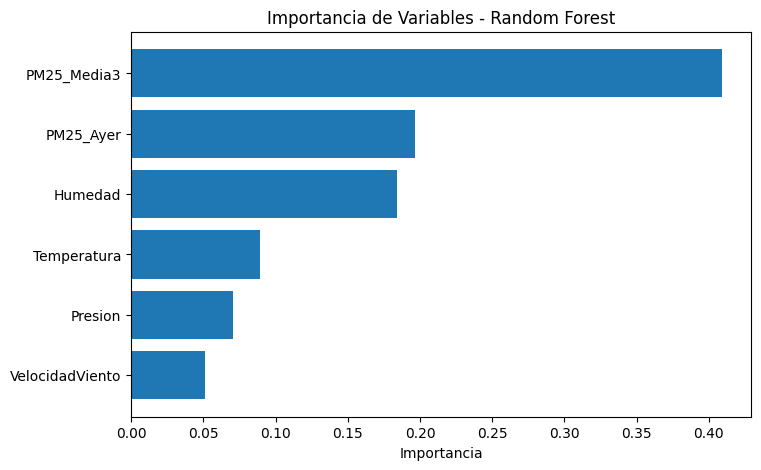

          Variable  Importancia
2  VelocidadViento     0.051368
3          Presion     0.070157
0      Temperatura     0.088850
1          Humedad     0.183946
4        PM25_Ayer     0.196740
5      PM25_Media3     0.408938


In [61]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia")

plt.show()

print(importancias)

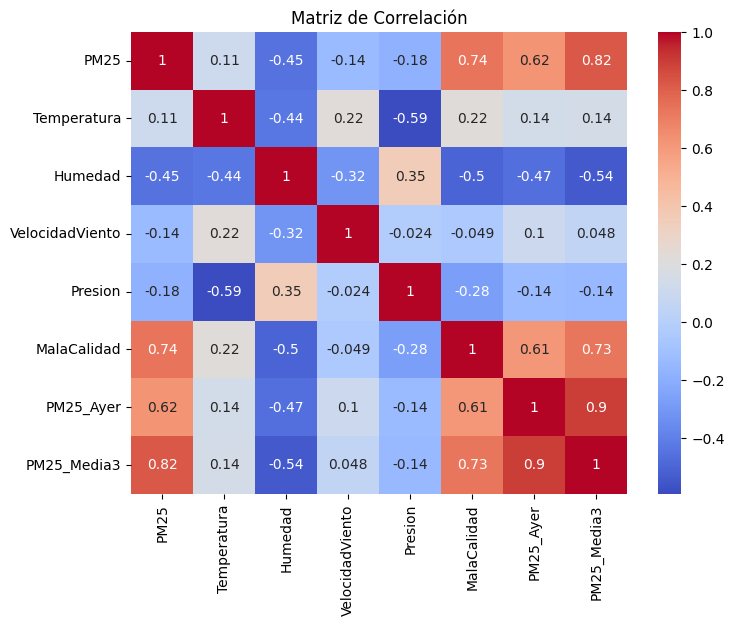

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Matriz de Correlación")
plt.show()

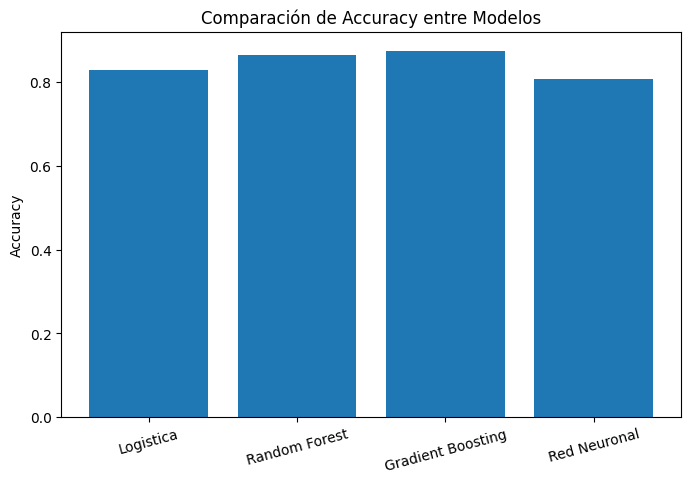

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    resultados["Modelo"],
    resultados["Accuracy"]
)

plt.title("Comparación de Accuracy entre Modelos")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()